# Preparação dos dados: os dados que entregamos estão "sujos", no seguinte sentido:
1. Há valores ausentes (missings) FEITO
2. Provavelmente há outliers FEITO
3. Slgumas variáveis são irrelevantes FEITO
4. Slgumas variáveis relevantes precisarão ser criadas FEITO
5. Mais filtros podem ser necessários
6. Os dados numéricos precisam ser normalizados FEITO
7. Os dados categóricos precisam ser codificados etc etc. FEITO
8. É fundamental que seja criado um Pipeline automatizado de preparação dos dados, ou seja, um script que consiga receber os dados brutos do SINAN e gerar os dados que nosso modelos usará para treinamento (isso porque, um dia, teremos mais dados e precisaremos atualizar o modelo). Padrão ouro: criar uma classe Python capaz de se integrar à um Pipeline de transformação da Scikit-Learn. FEITO



In [161]:
#  Importação de libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

import joblib

pd.options.display.float_format = '{:.3f}'.format

In [162]:
# Classe personalizada para detectar e tratar outliers
# utilizando o método IQR, integrada ao Pipeline do Scikit-Learn
class OutlierClipper(BaseEstimator, TransformerMixin):

    # aprende os limites dos outliers
    def fit(self, X, y=None):

        self.lower_bounds_ = []
        self.upper_bounds_ = []

        for j in range(X.shape[1]):

            col = pd.Series(X[:, j]).astype(float)

            Q1 = col.quantile(0.25)
            Q3 = col.quantile(0.75)

            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            self.lower_bounds_.append(lower)
            self.upper_bounds_.append(upper)

        return self

    # aplica o tratamento nos dados
    def transform(self, X, y=None):

        X = X.copy().astype(float)

        for j in range(X.shape[1]):

            X[:, j] = np.clip(
                X[:, j],
                self.lower_bounds_[j],
                self.upper_bounds_[j]
            )
        return X

In [163]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [164]:
import pandas as pd
# carregar dados
df = pd.read_csv("/content/drive/MyDrive/treino.csv")
df.head()

/tmp/ipykernel_545/1776252445.py:3: DtypeWarning: Columns (36,38,44,60,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/treino.csv")


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,NU_IDADE_N,...,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF,idade_unid,idade_val,idade_anos,ltfu
0,2,A169,2003-03-17,2003,11,110010,1483.000,20030317,1978.000,4024,...,0.000,0.000,0,0.000,NaN,NaN,4,24,24,0
1,2,A169,2005-06-10,2005,11,110010,1483.000,20050610,1957.000,4048,...,0.000,0.000,4,0.000,NaN,NaN,4,48,48,0
2,2,A169,2006-02-02,2006,35,355030,1331.000,20051220,1961.000,4044,...,7.000,0.000,1,0.000,NaN,NaN,4,44,44,0
3,2,A169,2006-01-24,2006,35,351640,1334.000,20051117,1980.000,4025,...,7.000,0.000,2,0.000,NaN,NaN,4,25,25,0
4,2,A169,2006-02-22,2006,35,350330,1345.000,20051229,1973.000,4032,...,7.000,0.000,3,0.000,NaN,NaN,4,32,32,0


# PREPARAÇÃO DOS DADOS

In [165]:
colunas = df.columns

for i in colunas:

  print(i)

TP_NOT
ID_AGRAVO
DT_NOTIFIC
NU_ANO
SG_UF_NOT
ID_MUNICIP
ID_REGIONA
DT_DIAG
ANO_NASC
NU_IDADE_N
CS_SEXO
CS_GESTANT
CS_RACA
CS_ESCOL_N
SG_UF
ID_MN_RESI
ID_RG_RESI
ID_PAIS
NDUPLIC_N
IN_VINCULA
DT_DIGITA
DT_TRANSUS
DT_TRANSDM
DT_TRANSSM
DT_TRANSRM
DT_TRANSRS
DT_TRANSSE
CS_FLXRET
FLXRECEBI
MIGRADO_W
ID_OCUPA_N
TRATAMENTO
INSTITUCIO
RAIOX_TORA
TESTE_TUBE
FORMA
EXTRAPU1_N
EXTRAPU2_N
EXTRAPUL_O
AGRAVAIDS
AGRAVALCOO
AGRAVDIABE
AGRAVDOENC
AGRAVOUTRA
AGRAVOUTDE
BACILOSC_E
BACILOS_E2
BACILOSC_O
CULTURA_ES
CULTURA_OU
HIV
HISTOPATOL
DT_INIC_TR
RIFAMPICIN
ISONIAZIDA
ETAMBUTOL
ESTREPTOMI
PIRAZINAMI
ETIONAMIDA
OUTRAS
OUTRAS_DES
TRAT_SUPER
NU_CONTATO
DOENCA_TRA
SG_UF_AT
ID_MUNIC_A
DT_NOTI_AT
SG_UF_2
ID_MUNIC_2
BACILOSC_1
BACILOSC_2
BACILOSC_3
BACILOSC_4
BACILOSC_5
BACILOSC_6
TRATSUP_AT
DT_MUDANCA
NU_COMU_EX
SITUA_9_M
SITUA_12_M
SITUA_ENCE
DT_ENCERRA
TPUNINOT
POP_LIBER
POP_RUA
POP_SAUDE
POP_IMIG
BENEF_GOV
AGRAVDROGA
AGRAVTABAC
TEST_MOLEC
TEST_SENSI
ANT_RETRO
BAC_APOS_6
TRANSF
UF_TRANSF
MUN_TRANSF
idade_u

In [166]:
variaveis_selecionadas = [
    "TRATAMENTO",      # tp_entrada
    "POP_RUA",         # tp_pop_rua
    "POP_LIBER",       # tp_pop_liberdade
    "POP_IMIG",        # tp_pop_imigrante
    "BENEF_GOV",       # tp_benef_gov
    "AGRAVALCOO",      # st_agravo_alcolismo
    "AGRAVDROGA",      # st_agravo_drogas
    "AGRAVDOENC",      # st_agravo_mental (aproximação)
    "AGRAVAIDS",       # st_agravo_aids
    "AGRAVDIABE",      # st_agravo_diabete
    "HIV",             # tp_hiv
    "FORMA",           # tp_forma
    "TRAT_SUPER",      # tp_tratamento_acompanhamento
    "idade_anos",      # idade
    "ID_MUNIC_A",      # municipio atual (aproximação)
    "POP_SAUDE",       # tp_pop_saúde
    "TEST_SENSI",      # tp_sensibilidade
    "BACILOSC_2",      # baciloscopia 2º mês (aproximação)
    "CS_ESCOL_N",      # escolaridade
    "CS_SEXO",         # sexo
    "ID_RG_RESI"       # zona (aproximação)
]

df_modelo = df[variaveis_selecionadas + ["ltfu"]].copy()

# criação de novas variáveis para ajudar o modelo
# a identificar padrões relacionados ao abandono do tratamento

# pacientes com maior vulnerabilidade social ou maior número
# de comorbidades podem apresentar maior risco de abandono
# do tratamento

# variável que soma fatores de vulnerabilidade social
cols_vulnerabilidade = [
    'POP_RUA',
    'POP_LIBER',
    'POP_IMIG',
    'AGRAVALCOO',
    'AGRAVDROGA',
    'AGRAVAIDS'
]

df_modelo['score_vulnerabilidade'] = (
    df_modelo[cols_vulnerabilidade]
    .fillna(0)
    .sum(axis=1)
)

# variável que conta quantas comorbidades o paciente possui
cols_comorbidades = [
    'AGRAVAIDS',
    'AGRAVDIABE',
    'AGRAVDOENC'
]

df_modelo['qtd_comorbidades'] = (
    df_modelo[cols_comorbidades]
    .fillna(0)
    .sum(axis=1)
)

# criação de faixas etárias para agrupar pacientes por idade
df_modelo['faixa_etaria'] = pd.cut(
    df_modelo['idade_anos'],
    bins=[18,30,45,60,120],
    labels=['18-30','31-45','46-60','60+']
)

df_modelo

,TRATAMENTO,POP_RUA,POP_LIBER,POP_IMIG,BENEF_GOV,AGRAVALCOO,AGRAVDROGA,AGRAVDOENC,AGRAVAIDS,AGRAVDIABE,...,POP_SAUDE,TEST_SENSI,BACILOSC_2,CS_ESCOL_N,CS_SEXO,ID_RG_RESI,ltfu,score_vulnerabilidade,qtd_comorbidades,faixa_etaria
0,1,2,2,2,9.000,9.000,9.000,9.000,9.000,9.000,...,2,0.000,3.000,9.000,M,1483.000,0,33.000,27.000,18-30
1,1,2,2,2,2.000,9.000,2.000,9.000,9.000,9.000,...,2,0.000,4.000,0.000,M,1483.000,0,26.000,27.000,46-60
2,1,2,2,2,0.000,1.000,2.000,2.000,2.000,2.000,...,2,7.000,0.000,3.000,M,1331.000,0,11.000,6.000,31-45
3,1,2,1,2,9.000,2.000,2.000,2.000,2.000,2.000,...,2,7.000,2.000,9.000,M,1334.000,0,11.000,6.000,18-30
4,1,2,2,2,0.000,2.000,2.000,1.000,2.000,2.000,...,2,7.000,3.000,10.000,M,1345.000,0,12.000,5.000,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562627,1,2,2,2,NaN,2.000,2.000,2.000,2.000,2.000,...,2,7.000,3.000,5.000,M,NaN,0,12.000,6.000,31-45
562628,1,2,2,2,2.000,2.000,2.000,2.000,1.000,2.000,...,2,NaN,2.000,0.000,F,558.000,0,11.000,5.000,46-60
562629,2,2,2,2,1.000,2.000,2.000,2.000,2.000,2.000,...,2,NaN,3.000,5.000,M,NaN,0,12.000,6.000,60+
562630,1,2,1,2,2.000,2.000,1.000,2.000,2.000,2.000,...,2,NaN,2.000,9.000,M,149.000,0,10.000,6.000,18-30


In [167]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562632 entries, 0 to 562631
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   TRATAMENTO             562632 non-null  int64   
 1   POP_RUA                562632 non-null  int64   
 2   POP_LIBER              562632 non-null  int64   
 3   POP_IMIG               562632 non-null  int64   
 4   BENEF_GOV              477019 non-null  float64 
 5   AGRAVALCOO             560105 non-null  float64 
 6   AGRAVDROGA             560223 non-null  float64 
 7   AGRAVDOENC             559007 non-null  float64 
 8   AGRAVAIDS              559158 non-null  float64 
 9   AGRAVDIABE             559984 non-null  float64 
 10  HIV                    561877 non-null  float64 
 11  FORMA                  562632 non-null  int64   
 12  TRAT_SUPER             262619 non-null  float64 
 13  idade_anos             562632 non-null  int64   
 14  ID_MUNIC_A          

In [168]:
# tratamento das colunas com padrão 9, que vira valores NaN
# Colunas com padrão SINAN 1=Sim / 2=Não / 9=Ignorado
colunas_com_9 = [
    'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV',
    'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE',
    'TRAT_SUPER', 'HIV', 'TEST_SENSI', 'BACILOSC_2', 'CS_ESCOL_N',
]
for col in colunas_com_9:
    df_modelo[col] = df_modelo[col].replace({9: np.nan, 9.0: np.nan})

# regras específicas por coluna

# TRATAMENTO: 4 = 'Não Sabe' → sem informação útil
df_modelo['TRATAMENTO'] = df_modelo['TRATAMENTO'].replace({4: np.nan})

# HIV: 3='Em andamento', 4='Não realizado' → não conclusivos
df_modelo['HIV'] = df_modelo['HIV'].replace({3: np.nan, 4: np.nan})

# TEST_SENSI: 6='Em andamento', 7='Não realizado' → não conclusivos
df_modelo['TEST_SENSI'] = df_modelo['TEST_SENSI'].replace({6: np.nan, 7: np.nan})

# BACILOSC_2: 3='Não realizada', 4='Não se aplica' (TB extrapulmonar) → sem info
df_modelo['BACILOSC_2'] = df_modelo['BACILOSC_2'].replace({3: np.nan, 4: np.nan})

# BENEF_GOV: apenas 1=Sim e 2=Não são válidos; 3,4,5 são inconsistências
df_modelo['BENEF_GOV'] = df_modelo['BENEF_GOV'].replace({3: np.nan, 4: np.nan, 5: np.nan})

# AGRAVAIDS / AGRAVDIABE: apenas 1=Sim e 2=Não são válidos; 3 é inconsistência
df_modelo['AGRAVAIDS']  = df_modelo['AGRAVAIDS'].replace({3: np.nan})

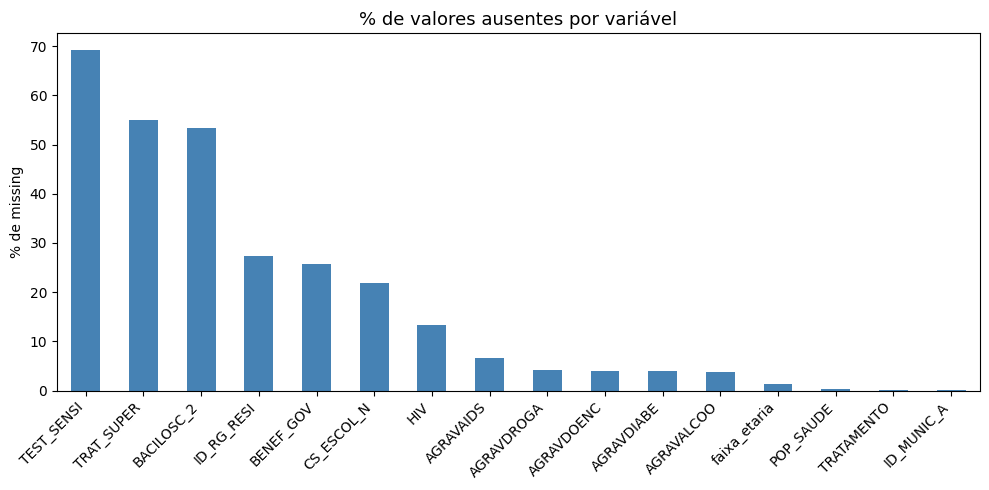

TEST_SENSI     69.300
TRAT_SUPER     55.000
BACILOSC_2     53.300
ID_RG_RESI     27.300
BENEF_GOV      25.600
CS_ESCOL_N     21.900
HIV            13.400
AGRAVAIDS       6.600
AGRAVDROGA      4.200
AGRAVDOENC      4.100
AGRAVDIABE      3.900
AGRAVALCOO      3.800
faixa_etaria    1.400
POP_SAUDE       0.300
TRATAMENTO      0.200
ID_MUNIC_A      0.000


In [169]:
# Visualizando o percentual de missings por coluna
missing = df_modelo.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

# aqui seria a criação de um grafico com os percentuais, não sei se querem ou não
plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='steelblue')
plt.title('% de valores ausentes por variável', fontsize=13)
plt.ylabel('% de missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(missing.round(1).to_string())

In [170]:
# Tratamento variavel binaria SINAN, que será transofrmada para 0 = Não e 1 = Sim
cols_binarias_sinan = [
    'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV',
    'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE',
    'TRAT_SUPER',
]

for col in cols_binarias_sinan:
    df_modelo[col] = df_modelo[col].replace({2: 0, 2.0: 0})

# Verificação: cada coluna deve ter apenas 0.0, 1.0 e NaN
print('Valores únicos após conversão (sem NaN):')
for col in cols_binarias_sinan:
    unicos = sorted(df_modelo[col].dropna().unique())
    print(f'  {col:15s}: {unicos}')

Valores únicos após conversão (sem NaN):
  POP_RUA        : [np.int64(0), np.int64(1)]
  POP_LIBER      : [np.int64(0), np.int64(1)]
  POP_IMIG       : [np.int64(0), np.int64(1)]
  POP_SAUDE      : [np.float64(0.0)]
  BENEF_GOV      : [np.float64(0.0), np.float64(1.0)]
  AGRAVALCOO     : [np.float64(0.0), np.float64(1.0)]
  AGRAVDROGA     : [np.float64(0.0), np.float64(1.0)]
  AGRAVDOENC     : [np.float64(0.0), np.float64(1.0)]
  AGRAVAIDS      : [np.float64(0.0), np.float64(1.0)]
  AGRAVDIABE     : [np.float64(0.0), np.float64(1.0), np.float64(3.0)]
  TRAT_SUPER     : [np.float64(0.0), np.float64(1.0)]


In [171]:
# separarando as variáveis por tipo pra saber como tratar cada uma depois

# Variáveis numéricas contínuas
cols_numericas = [
    'idade_anos',
    'score_vulnerabilidade',
    'qtd_comorbidades'
]

# Variáveis binárias SINAN (1=Sim, 2=Não) — vamos converter para 1/0
cols_binarias_sinan = [
    'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV',
    'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE',
    'TRAT_SUPER',
]

# Variáveis categóricas com múltiplos valores significativos
cols_categoricas = [
    'CS_SEXO',      # M / F / I
    'FORMA',        # 1=Pulmonar, 2=Extrapulmonar, 3=Ambas
    'TRATAMENTO',   # 1=Caso novo, 2=Recidiva, 3=Reingresso, 5=Transferência, 6=Pós-óbito
    'HIV',          # 1=Positivo, 2=Negativo
    'TEST_SENSI',   # 1-5: diferentes padrões de resistência / 5=Sensível
    'BACILOSC_2',   # 1=Positiva, 2=Negativa
    'CS_ESCOL_N',   # escolaridade (ordinal)
    'faixa_etaria'
]

# ID do município — trataremos como categorica
cols_municipio = ['ID_MUNIC_A', 'ID_RG_RESI']


all_features = cols_numericas + cols_binarias_sinan + cols_categoricas + cols_municipio
print(f'Total de features: {len(all_features)}')
print('\nFeatures:', all_features)

Total de features: 24

Features: ['idade_anos', 'score_vulnerabilidade', 'qtd_comorbidades', 'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV', 'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE', 'TRAT_SUPER', 'CS_SEXO', 'FORMA', 'TRATAMENTO', 'HIV', 'TEST_SENSI', 'BACILOSC_2', 'CS_ESCOL_N', 'faixa_etaria', 'ID_MUNIC_A', 'ID_RG_RESI']


# CONSTRUÇÃO DO PIPELINE USANDO SKLEARN

In [172]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """
    Transforma IDs de município/região em rankings de frequência.
    Municípios mais comuns recebem valores menores (rank 0, 1, 2...).
    Municípios não vistos no treino recebem o rank máximo + 1.
    Isso é melhor que OrdinalEncoder puro porque preserva informação
    epidemiológica regional (municípios com mais casos tendem a ter
    contextos diferentes dos municípios com poucos casos).
    """
    def fit(self, X, y=None):
        self.maps_ = []
        for j in range(X.shape[1]):
            col = pd.Series(X[:, j]).fillna('desconhecido').astype(str)
            freq = col.value_counts()
            self.maps_.append({val: rank for rank, val in enumerate(freq.index)})
        return self

    def transform(self, X, y=None):
        result = np.zeros((X.shape[0], X.shape[1]))
        for j in range(X.shape[1]):
            col = pd.Series(X[:, j]).fillna('desconhecido').astype(str)
            result[:, j] = col.map(self.maps_[j]).fillna(len(self.maps_[j]))
        return result

print('FrequencyEncoder definido!')

FrequencyEncoder definido!


In [173]:
# Sub-pipeline para numéricas: imputa mediana → normaliza
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier', OutlierClipper()),
    ('scaler', StandardScaler()),
])

# Sub-pipeline para binárias: imputa moda (sem scaler — já são 0/1)
pipe_bin = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

# Sub-pipeline para categóricas: imputa moda → codifica como inteiro
pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

# Sub-pipeline para IDs de município/região: encoding por frequência
pipe_mun = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=np.nan)),
    ('encoder', FrequencyEncoder()),
])

# ColumnTransformer: orquestra tudo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipe_num, cols_numericas),
        ('bin', pipe_bin, cols_binarias_sinan),
        ('cat', pipe_cat, cols_categoricas),
        ('mun', pipe_mun, cols_municipio),
    ],
    remainder='drop'
)

print('Pipeline montado com sucesso!')

Pipeline montado com sucesso!


In [174]:
# X, y
X = df_modelo.drop("ltfu", axis=1)
y = df_modelo["ltfu"]

# split treino-teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=12
    )

# TREINANDO PIPLINE

In [175]:
# Fit APENAS no treino — aprende mediana, moda, categorias, etc.
preprocessor.fit(X_train)

# Transforma treino e teste com os mesmos parâmetros aprendidos
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Shape treino processado: {X_train_proc.shape}')
print(f'Shape teste processado:  {X_test_proc.shape}')
print(f'\nNaN restantes — Treino: {np.isnan(X_train_proc).sum()} | Teste: {np.isnan(X_test_proc).sum()}')

Shape treino processado: (450105, 24)
Shape teste processado:  (112527, 24)

NaN restantes — Treino: 0 | Teste: 0


In [176]:
# Recriar como DataFrame para facilitar análises
col_names = cols_numericas + cols_binarias_sinan + cols_categoricas + cols_municipio
X_train_df = pd.DataFrame(X_train_proc, columns=col_names)
X_test_df  = pd.DataFrame(X_test_proc,  columns=col_names)

print('Primeiras linhas do treino processado:')
X_train_df.head()

Primeiras linhas do treino processado:


,idade_anos,score_vulnerabilidade,qtd_comorbidades,POP_RUA,POP_LIBER,POP_IMIG,POP_SAUDE,BENEF_GOV,AGRAVALCOO,AGRAVDROGA,...,CS_SEXO,FORMA,TRATAMENTO,HIV,TEST_SENSI,BACILOSC_2,CS_ESCOL_N,faixa_etaria,ID_MUNIC_A,ID_RG_RESI
0,1.769,0.459,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,...,2.000,0.000,0.000,2.000,1.000,2.000,0.000,3.000,251.000,4.000
1,-0.597,1.988,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,2.000,0.000,0.000,1.000,1.000,2.000,1.000,1.000,23.000,12.000
2,-1.109,0.459,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,2.000,0.000,0.000,2.000,1.000,2.000,4.000,0.000,0.000,0.000
3,0.490,0.459,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,2.000,0.000,0.000,2.000,0.000,2.000,0.000,2.000,197.000,151.000
4,1.002,0.459,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,2.000,1.000,2.000,5.000,2.000,7.000,3.000


# ANALISE

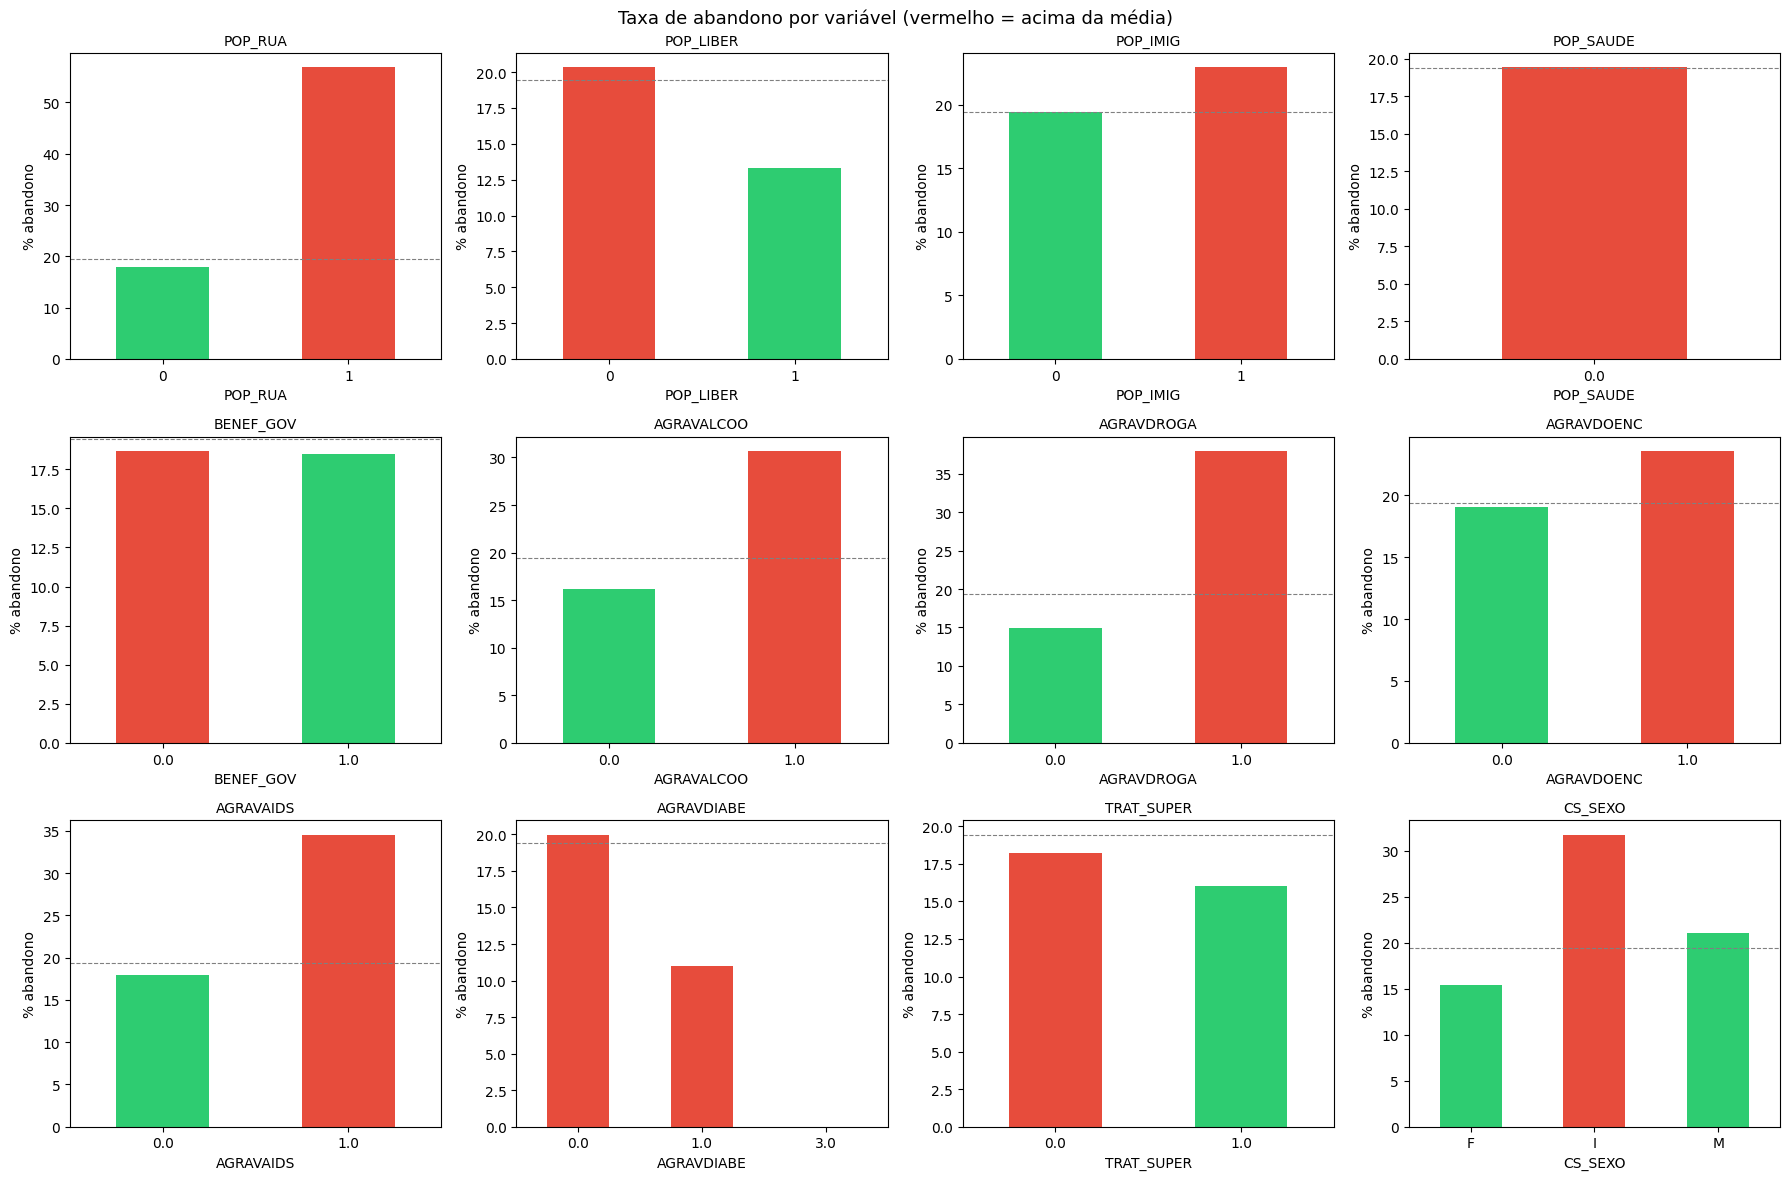

In [177]:
TARGET = 'ltfu'

# Taxa de abandono por variáveis binárias
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(cols_binarias_sinan + ['CS_SEXO']):
    taxa = df_modelo.groupby(col)[TARGET].mean() * 100
    cores = ['#2ecc71' if v < taxa.mean() else '#e74c3c' for v in taxa]
    taxa.plot(kind='bar', ax=axes[i], color=cores)
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_ylabel('% abandono')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].axhline(df_modelo[TARGET].mean()*100, color='gray', linestyle='--', linewidth=0.8, label='média geral')

for j in range(len(cols_binarias_sinan)+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Taxa de abandono por variável (vermelho = acima da média)', fontsize=13)
plt.tight_layout()
plt.show()

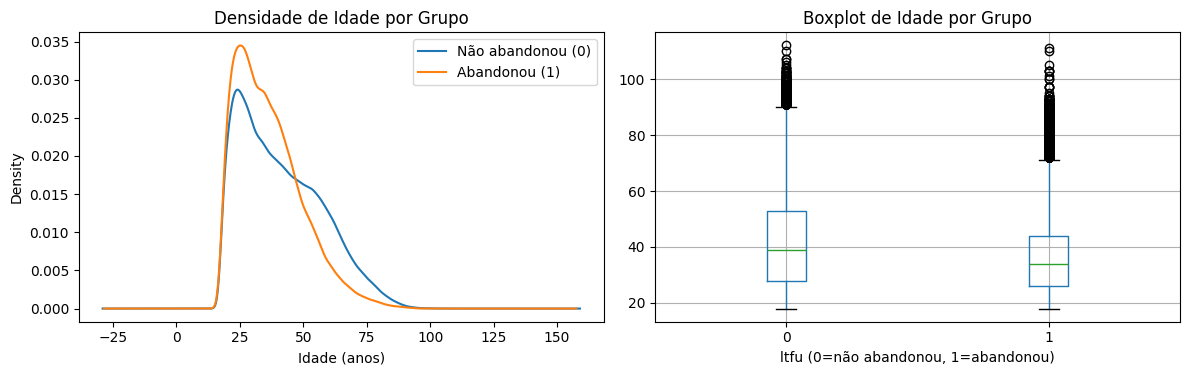

Média de idade por grupo:
ltfu
0   41.257
1   36.567
Name: idade_anos, dtype: float64


In [178]:
# Distribuição de idade por grupo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_modelo.groupby(TARGET)['idade_anos'].plot(
    kind='density', ax=axes[0]
)
axes[0].set_title('Densidade de Idade por Grupo')
axes[0].set_xlabel('Idade (anos)')
axes[0].legend(['Não abandonou (0)', 'Abandonou (1)'])

df_modelo.boxplot(column='idade_anos', by=TARGET, ax=axes[1])
axes[1].set_title('Boxplot de Idade por Grupo')
axes[1].set_xlabel('ltfu (0=não abandonou, 1=abandonou)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Média de idade por grupo:')
print(df_modelo.groupby(TARGET)['idade_anos'].mean())

In [179]:
df_modelo.groupby("ltfu")["idade_anos"].mean()

,idade_anos
ltfu,
0,41.257
1,36.567


In [180]:
pd.crosstab(df_modelo["CS_SEXO"], df_modelo["ltfu"], normalize="index")

ltfu,0,1
CS_SEXO,,
F,0.846,0.154
I,0.683,0.317
M,0.790,0.210


In [181]:
pd.crosstab(df_modelo["ltfu"], df_modelo["CS_SEXO"], normalize="columns")

CS_SEXO,F,I,M
ltfu,,,
0,0.846,0.683,0.790
1,0.154,0.317,0.210


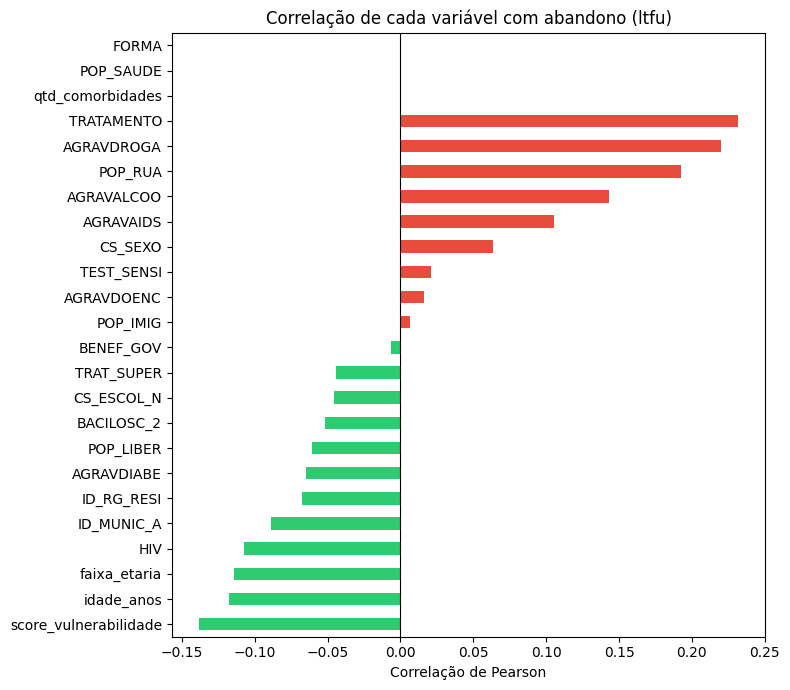

In [182]:
# Correlação com o target (nos dados processados)
X_train_df['ltfu'] = y_train.values
corr = X_train_df.corr()['ltfu'].drop('ltfu').sort_values()

plt.figure(figsize=(8, 7))
corr.plot(kind='barh',
          color=corr.map(lambda v: '#e74c3c' if v > 0 else '#2ecc71'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação de cada variável com abandono (ltfu)', fontsize=12)
plt.xlabel('Correlação de Pearson')
plt.tight_layout()
plt.show()

X_train_df = X_train_df.drop(columns='ltfu')

In [183]:
# Salvar o pipeline treinado
joblib.dump(preprocessor, '/content/drive/MyDrive/preprocessor.pkl')
print('preprocessor.pkl salvo!')

# Salvar dados processados
X_train_df.to_csv('/content/drive/MyDrive/X_train_proc.csv', index=False)
X_test_df.to_csv( '/content/drive/MyDrive/X_test_proc.csv',  index=False)
y_train.reset_index(drop=True).to_csv('/content/drive/MyDrive/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv( '/content/drive/MyDrive/y_test.csv',  index=False)

print('X_train_proc.csv, X_test_proc.csv, y_train.csv, y_test.csv salvos!')
print(f'\nFeatures finais ({len(col_names)}): {col_names}')

preprocessor.pkl salvo!
X_train_proc.csv, X_test_proc.csv, y_train.csv, y_test.csv salvos!

Features finais (24): ['idade_anos', 'score_vulnerabilidade', 'qtd_comorbidades', 'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV', 'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE', 'TRAT_SUPER', 'CS_SEXO', 'FORMA', 'TRATAMENTO', 'HIV', 'TEST_SENSI', 'BACILOSC_2', 'CS_ESCOL_N', 'faixa_etaria', 'ID_MUNIC_A', 'ID_RG_RESI']


In [184]:
# processar teste2 com o pipeline já treinado
teste2 = pd.read_csv('/content/drive/MyDrive/teste2.csv', low_memory=False)

teste2['score_vulnerabilidade'] = (
    teste2[['POP_RUA','POP_LIBER','POP_IMIG','AGRAVALCOO','AGRAVDROGA','AGRAVAIDS']]
    .fillna(0).sum(axis=1)
)
teste2['qtd_comorbidades'] = (
    teste2[['AGRAVAIDS','AGRAVDIABE','AGRAVDOENC']]
    .fillna(0).sum(axis=1)
)
teste2['faixa_etaria'] = pd.cut(
    teste2['idade_anos'],
    bins=[18, 30, 45, 60, 120],
    labels=['18-30', '31-45', '46-60', '60+']
)

X_test2_proc = preprocessor.transform(teste2[all_features])
y_test2 = teste2['ltfu']

pd.DataFrame(X_test2_proc, columns=col_names).to_csv('/content/drive/MyDrive/X_test2_proc.csv', index=False)
y_test2.reset_index(drop=True).to_csv('/content/drive/MyDrive/y_test2.csv', index=False)

print(f'X_test2_proc.csv salvo! Shape: {X_test2_proc.shape}')

X_test2_proc.csv salvo! Shape: (631, 24)
